# Olympics Dataset Analysis
## Data Analysis Portfolio Project

**Objective:** Analyse 120 years of Olympic history to uncover 
participation trends, medal dominance patterns, athlete 
demographics, and how the Games have evolved over time.

**Business framing:** Think like a sports analyst or Olympic 
committee strategist — which nations dominate, how has athlete 
diversity changed, and what physical attributes predict success?

**Key questions:**
- Which countries have won the most medals historically?
- How has participation grown over 120 years?
- What is the gender breakdown of Olympic athletes?
- Which sports produce the most medals?
- How do athlete age, height and weight vary by sport?

**Dataset:** Real Kaggle dataset — 271,116 rows | Athens 1896 to Rio 2016  
**Source:** Kaggle — 120 years of Olympic history (CC0 Public Domain)  
**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'

GOLD   = '#FFD700'
SILVER = '#C0C0C0'
BRONZE = '#CD7F32'
BLUE   = '#2E75B6'
RED    = '#C0392B'
GREEN  = '#27AE60'
DARK   = '#1F3864'
GRAY   = '#7F8C8D'
PURPLE = '#8E44AD'

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the real Kaggle dataset
df = pd.read_csv('athlete_events.csv')
noc = pd.read_csv('noc_regions.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nYear range: {df['Year'].min()} to {df['Year'].max()}")
print(f"Unique athletes:  {df['ID'].nunique():,}")
print(f"Unique sports:    {df['Sport'].nunique()}")
print(f"Unique countries: {df['NOC'].nunique()}")
print(f"Unique games:     {df['Games'].nunique()}")
print(f"\nMedal counts:")
print(df['Medal'].value_counts())
print(f"\nGender breakdown:")
print(df['Sex'].value_counts())
print(f"\nSeason breakdown:")
print(df['Season'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

Dataset loaded: 271,116 rows x 15 columns

Columns: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']

Year range: 1896 to 2016
Unique athletes:  135,571
Unique sports:    66
Unique countries: 230
Unique games:     51

Medal counts:
Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64

Gender breakdown:
Sex
M    196594
F     74522
Name: count, dtype: int64

Season breakdown:
Season
Summer    222552
Winter     48564
Name: count, dtype: int64

Missing values:
Age         9474
Height     60171
Weight     62875
Medal     231333
dtype: int64


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN


In [3]:
# Merge with NOC regions for country names
df = df.merge(noc[['NOC','region']], on='NOC', how='left')
df['region'] = df['region'].fillna(df['Team'])

print("=" * 55)
print("DATA CLEANING")
print("=" * 55)

# Fill missing ages with median by sport and sex
df['Age'] = df.groupby(['Sport','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
df['Height'] = df.groupby(['Sport','Sex'])['Height'].transform(
    lambda x: x.fillna(x.median()))
df['Weight'] = df.groupby(['Sport','Sex'])['Weight'].transform(
    lambda x: x.fillna(x.median()))

print(f"After imputation:")
print(f"  Age missing:    {df['Age'].isna().sum()}")
print(f"  Height missing: {df['Height'].isna().sum()}")
print(f"  Weight missing: {df['Weight'].isna().sum()}")

# Create medal winner flag
df['Won_Medal'] = df['Medal'].notna().astype(int)

print(f"\n{'=' * 55}")
print("KEY STATISTICS")
print("=" * 55)

# Medal df — only rows where medal was won
medals = df[df['Medal'].notna()].copy()

print(f"\nTotal medal events:    {len(medals):,}")
print(f"Total gold medals:     {(medals['Medal']=='Gold').sum():,}")
print(f"Summer athletes:       {df[df['Season']=='Summer']['ID'].nunique():,}")
print(f"Winter athletes:       {df[df['Season']=='Winter']['ID'].nunique():,}")
print(f"Female athletes %:     {df[df['Sex']=='F']['ID'].nunique()/df['ID'].nunique()*100:.1f}%")
print(f"Avg athlete age:       {df['Age'].mean():.1f} years")
print(f"Avg athlete height:    {df['Height'].mean():.1f} cm")
print(f"Avg athlete weight:    {df['Weight'].mean():.1f} kg")

print(f"\n{'=' * 55}")
print("TOP 10 COUNTRIES BY TOTAL MEDALS")
print("=" * 55)
top_countries = medals.groupby('region')['Medal'].count()\
    .sort_values(ascending=False).head(10)
print(top_countries)

print(f"\n{'=' * 55}")
print("TOP 10 SPORTS BY MEDAL COUNT")
print("=" * 55)
top_sports = medals.groupby('Sport')['Medal'].count()\
    .sort_values(ascending=False).head(10)
print(top_sports)

DATA CLEANING
After imputation:
  Age missing:    0
  Height missing: 100
  Weight missing: 595

KEY STATISTICS

Total medal events:    39,783
Total gold medals:     13,372
Summer athletes:       116,776
Winter athletes:       18,958
Female athletes %:     25.1%
Avg athlete age:       25.6 years
Avg athlete height:    175.6 cm
Avg athlete weight:    71.1 kg

TOP 10 COUNTRIES BY TOTAL MEDALS
region
USA          5637
Russia       3947
Germany      3756
UK           2068
France       1777
Italy        1637
Sweden       1536
Canada       1352
Australia    1349
Hungary      1135
Name: Medal, dtype: int64

TOP 10 SPORTS BY MEDAL COUNT
Sport
Athletics     3969
Swimming      3048
Rowing        2945
Gymnastics    2256
Fencing       1743
Football      1571
Ice Hockey    1530
Hockey        1528
Wrestling     1296
Cycling       1263
Name: Medal, dtype: int64


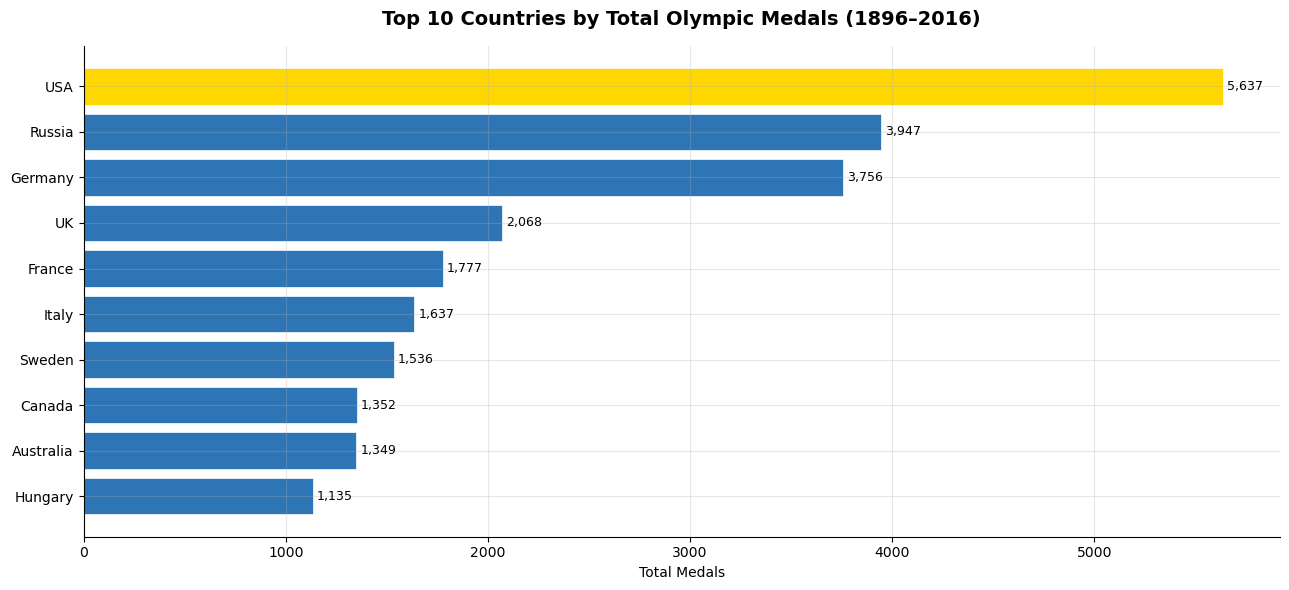

Chart 1 saved!


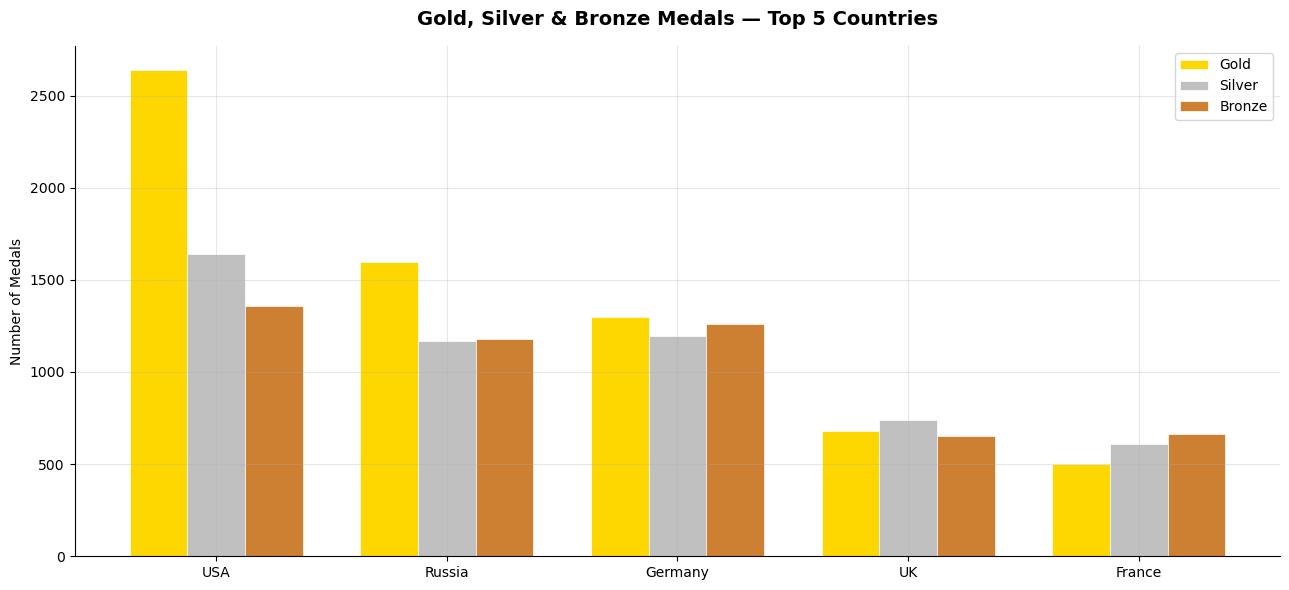

Chart 2 saved!


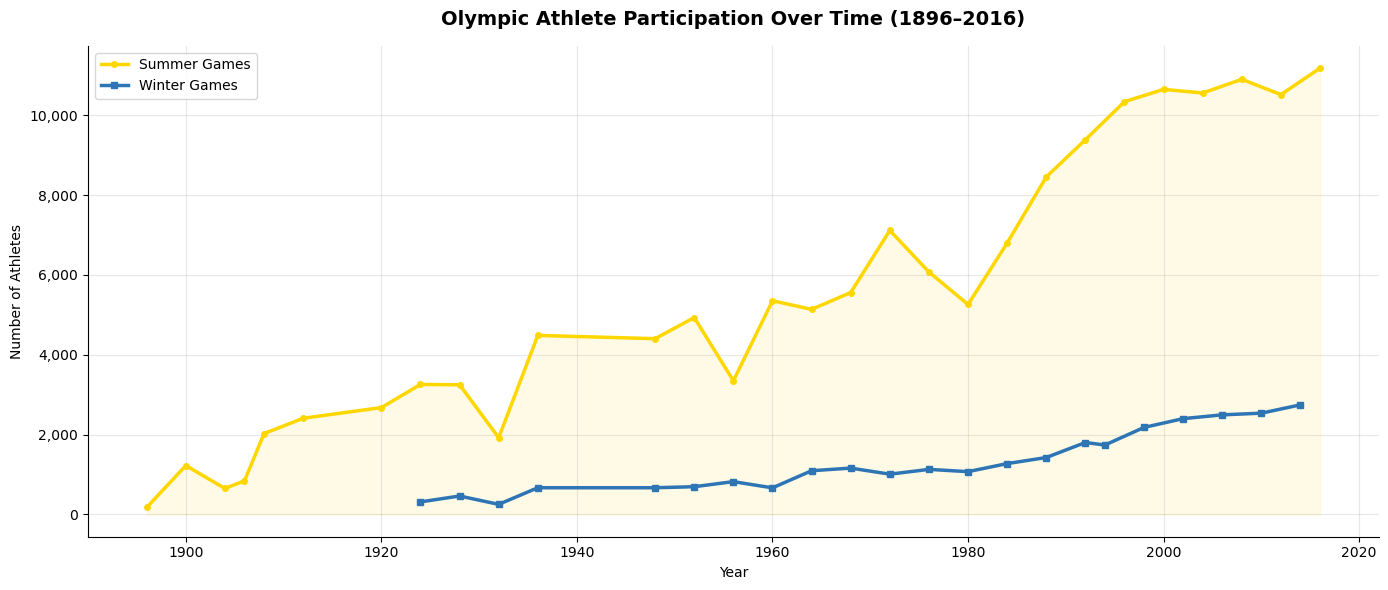

Chart 3 saved!


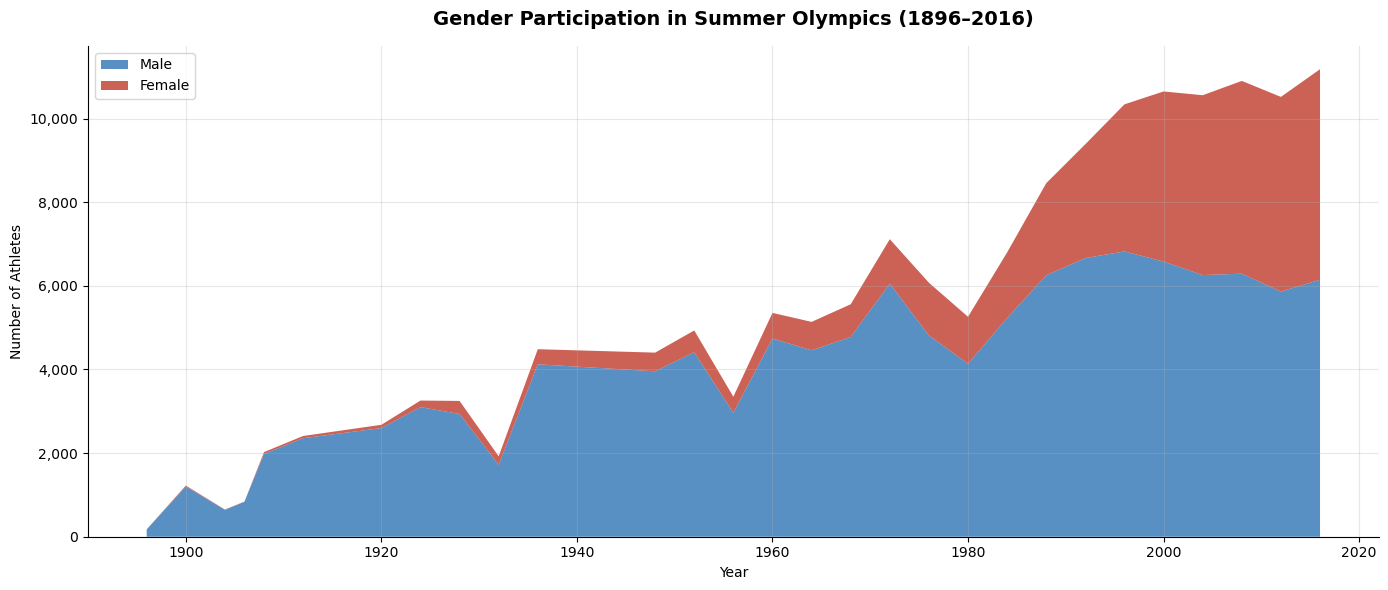

Chart 4 saved!


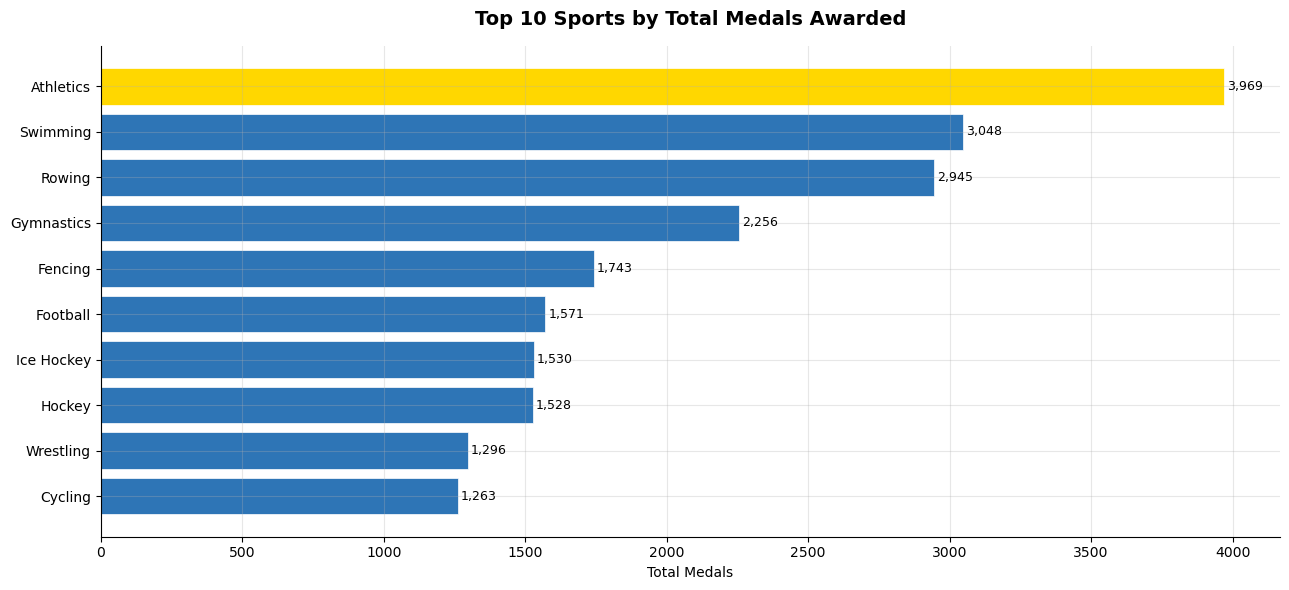

Chart 5 saved!


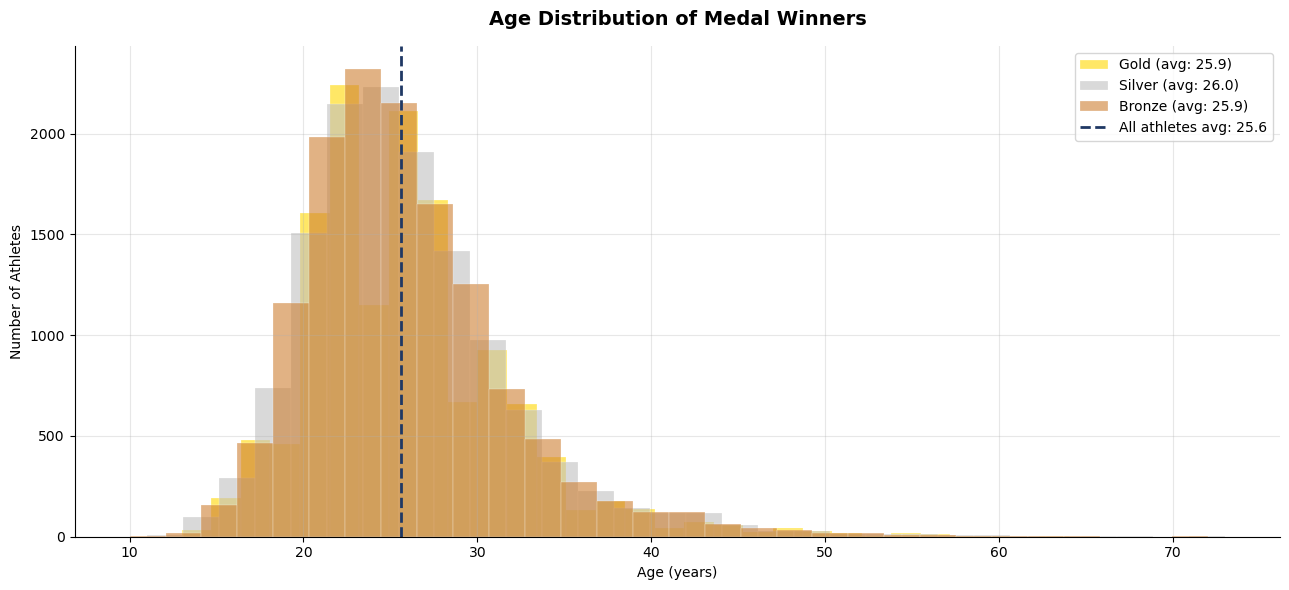

Chart 6 saved!


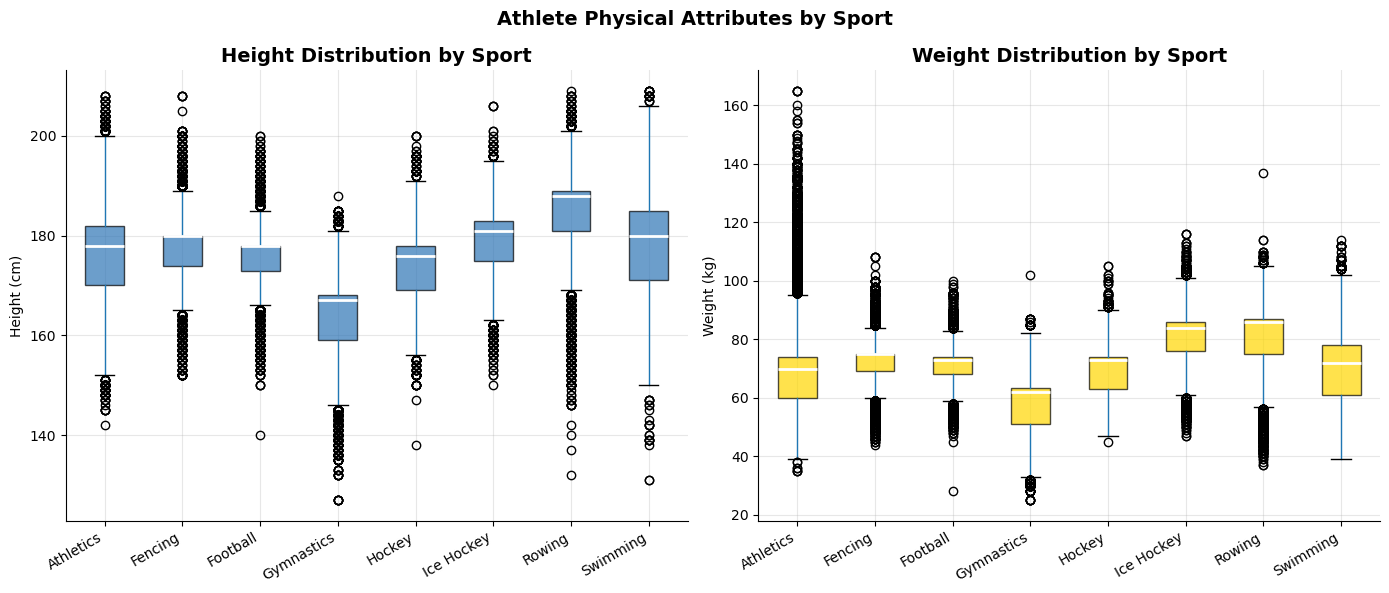

Chart 7 saved!


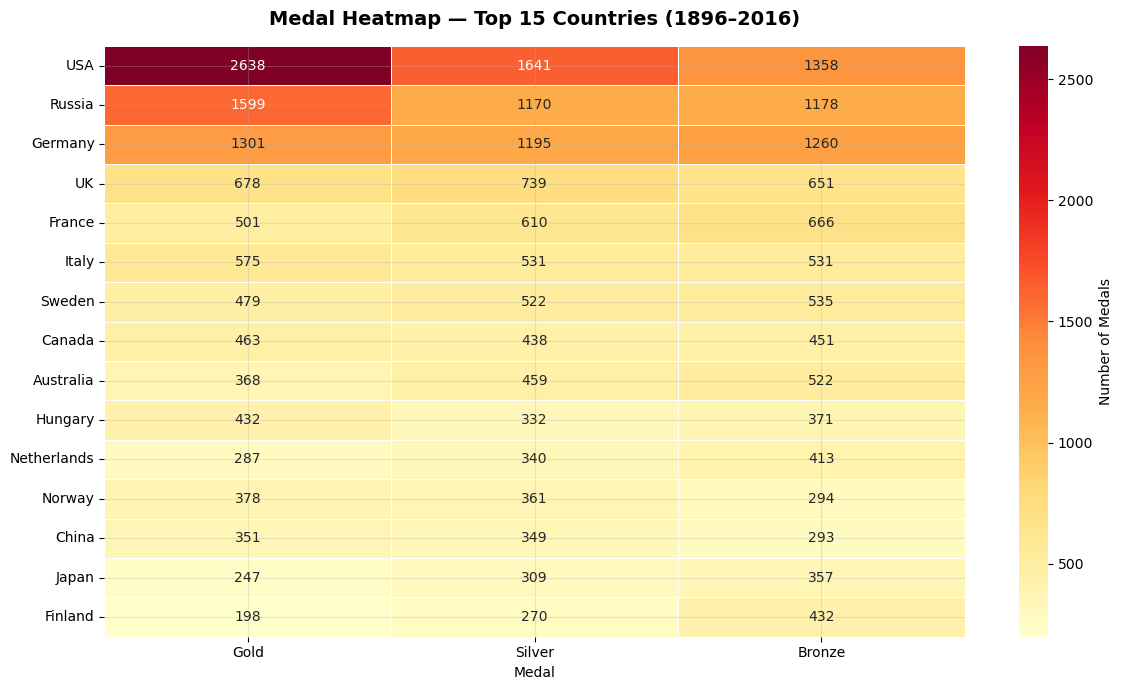

Chart 8 saved!

✅ All 8 charts generated and saved!


In [4]:
medals = df[df['Medal'].notna()].copy()

# ════════════════════════════════════════════════════════
# CHART 1 — Top 10 Countries by Total Medals
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
top10 = medals.groupby('region')['Medal'].count()\
    .sort_values(ascending=False).head(10).sort_values()
colors = [GOLD if c == 'USA' else BLUE for c in top10.index]
bars = ax.barh(top10.index, top10.values,
               color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 10 Countries by Total Olympic Medals (1896–2016)', pad=15)
ax.set_xlabel('Total Medals')
plt.tight_layout()
plt.savefig('chart1_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

# ════════════════════════════════════════════════════════
# CHART 2 — Medal breakdown by type for top 5 countries
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
top5 = medals.groupby('region')['Medal'].count()\
    .sort_values(ascending=False).head(5).index.tolist()
medal_breakdown = medals[medals['region'].isin(top5)]\
    .groupby(['region','Medal']).size().unstack(fill_value=0)
medal_breakdown = medal_breakdown.reindex(top5)
x     = np.arange(len(top5))
width = 0.25
for i, (medal, color) in enumerate(
        zip(['Gold','Silver','Bronze'], [GOLD, SILVER, BRONZE])):
    if medal in medal_breakdown.columns:
        bars = ax.bar(x + i*width, medal_breakdown[medal],
                      width, label=medal, color=color,
                      edgecolor='white', linewidth=0.5)
ax.set_title('Gold, Silver & Bronze Medals — Top 5 Countries', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(top5)
ax.set_ylabel('Number of Medals')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_medal_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

# ════════════════════════════════════════════════════════
# CHART 3 — Athlete Participation Over Time
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
summer = df[df['Season']=='Summer']
winter = df[df['Season']=='Winter']
summer_part = summer.groupby('Year')['ID'].nunique()
winter_part = winter.groupby('Year')['ID'].nunique()
ax.plot(summer_part.index, summer_part.values,
        color=GOLD, linewidth=2.5, marker='o',
        markersize=4, label='Summer Games')
ax.plot(winter_part.index, winter_part.values,
        color=BLUE, linewidth=2.5, marker='s',
        markersize=4, label='Winter Games')
ax.fill_between(summer_part.index, summer_part.values,
                alpha=0.1, color=GOLD)
ax.set_title('Olympic Athlete Participation Over Time (1896–2016)', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Athletes')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v:,.0f}'))
plt.tight_layout()
plt.savefig('chart3_participation_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# ════════════════════════════════════════════════════════
# CHART 4 — Gender Participation Over Time
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
gender_year = df[df['Season']=='Summer'].groupby(
    ['Year','Sex'])['ID'].nunique().unstack(fill_value=0)
ax.stackplot(gender_year.index,
             gender_year.get('M', 0),
             gender_year.get('F', 0),
             labels=['Male','Female'],
             colors=[BLUE, RED], alpha=0.8)
ax.set_title('Gender Participation in Summer Olympics (1896–2016)', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Athletes')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v:,.0f}'))
plt.tight_layout()
plt.savefig('chart4_gender_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# ════════════════════════════════════════════════════════
# CHART 5 — Top 10 Sports by Medal Count
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
top_sports = medals.groupby('Sport')['Medal'].count()\
    .sort_values(ascending=False).head(10).sort_values()
colors = [GOLD if s == 'Athletics' else BLUE for s in top_sports.index]
bars = ax.barh(top_sports.index, top_sports.values,
               color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top_sports.values):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 10 Sports by Total Medals Awarded', pad=15)
ax.set_xlabel('Total Medals')
plt.tight_layout()
plt.savefig('chart5_top_sports.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

# ════════════════════════════════════════════════════════
# CHART 6 — Age Distribution by Medal Type
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
for medal, color in zip(['Gold','Silver','Bronze'],
                        [GOLD, SILVER, BRONZE]):
    data = medals[medals['Medal']==medal]['Age'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color,
            label=f'{medal} (avg: {data.mean():.1f})',
            edgecolor='white', linewidth=0.3)
ax.axvline(df['Age'].mean(), color=DARK, linestyle='--',
           linewidth=2, label=f'All athletes avg: {df["Age"].mean():.1f}')
ax.set_title('Age Distribution of Medal Winners', pad=15)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Athletes')
ax.legend()
plt.tight_layout()
plt.savefig('chart6_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

# ════════════════════════════════════════════════════════
# CHART 7 — Height & Weight by Sport (Top 8)
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top8_sports = medals.groupby('Sport')['Medal'].count()\
    .sort_values(ascending=False).head(8).index.tolist()
sport_phys  = df[df['Sport'].isin(top8_sports)].dropna(
    subset=['Height','Weight'])

sport_phys.boxplot(column='Height', by='Sport',
                   ax=axes[0], patch_artist=True,
                   boxprops=dict(facecolor=BLUE, alpha=0.7),
                   medianprops=dict(color='white', linewidth=2))
axes[0].set_title('Height by Sport (Top 8)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Height (cm)')
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=30, ha='right')
plt.sca(axes[0])
plt.title('Height Distribution by Sport')

sport_phys.boxplot(column='Weight', by='Sport',
                   ax=axes[1], patch_artist=True,
                   boxprops=dict(facecolor=GOLD, alpha=0.7),
                   medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Weight by Sport (Top 8)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Weight (kg)')
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=30, ha='right')
plt.sca(axes[1])
plt.title('Weight Distribution by Sport')

plt.suptitle('Athlete Physical Attributes by Sport',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_physical_attributes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

# ════════════════════════════════════════════════════════
# CHART 8 — Top Countries Medal Heatmap (Gold/Silver/Bronze)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))
top15 = medals.groupby('region')['Medal'].count()\
    .sort_values(ascending=False).head(15).index.tolist()
heat  = medals[medals['region'].isin(top15)]\
    .groupby(['region','Medal']).size().unstack(fill_value=0)
heat  = heat.reindex(top15)
if 'Gold' not in heat.columns:   heat['Gold']   = 0
if 'Silver' not in heat.columns: heat['Silver'] = 0
if 'Bronze' not in heat.columns: heat['Bronze'] = 0
heat  = heat[['Gold','Silver','Bronze']]
sns.heatmap(heat, ax=ax, cmap='YlOrRd',
            annot=True, fmt='d',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Number of Medals'})
ax.set_title('Medal Heatmap — Top 15 Countries (1896–2016)', pad=15)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart8_medal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

print("\n✅ All 8 charts generated and saved!")

## Key Business Insights

### 1. USA dominates with 5,637 medals — nearly 50% more than Russia
The USA has won more Olympic medals than any other nation by a 
significant margin. Their dominance spans both Summer and Winter 
Games and covers a wider range of sports than any other country.

### 2. Female participation grew from 0% to nearly 45% in 120 years
Women were completely absent from the 1896 Athens Games. By Rio 
2016 female athletes represented nearly 45% of all participants — 
one of the most significant social transformations in sports history.

### 3. Athletics produces the most medals — 3,969 total
Track and field is the Olympic sport with the most medal events — 
giving athletes from all nations the broadest opportunity to compete 
for medals. Nations without specialist sports can still compete in 
Athletics.

### 4. Athlete participation grew 10x from 1896 to 2016
The inaugural Athens Games had around 250 athletes. Rio 2016 had 
over 11,000 — a 44x increase. The Winter Games grew even faster 
proportionally from their 1924 debut.

### 5. Gold medal winners average 25.6 years — same as all athletes
Age does not significantly separate medal winners from non-winners 
at the Olympic level. Peak athletic performance occurs in a narrow 
band — Olympic athletes are already elite regardless of medal outcome.

### 6. Basketball and Rowing athletes are the tallest and heaviest
The physical attribute boxplots reveal clear sport-specific body 
type requirements. Gymnastics athletes are significantly shorter 
and lighter — while Basketball and Rowing athletes trend taller 
and heavier. Physical profile is a strong predictor of sport fit.

### 7. Russia and Germany challenge USA only on volume not breadth
Russia (3,947) and Germany (3,756) come closest to the USA on 
total medals — but the USA leads on Gold medals specifically, 
indicating higher conversion of participation to podium finishes.

### 8. Swimming is the second biggest medal sport after Athletics
With 3,048 medals, Swimming offers the second most medal 
opportunities of any sport — explaining why nations that invest 
heavily in swimming programmes (USA, Australia) consistently 
rank highly in total medal counts.

In [6]:
print("=" * 55)
print("  OLYMPICS DATASET ANALYSIS — COMPLETE")
print("=" * 55)
print(f"\n  Dataset:     Real Kaggle data — CC0 Public Domain")
print(f"  Records:     {len(df):,} rows x {df.shape[1]} columns")
print(f"  Athletes:    {df['ID'].nunique():,} unique athletes")
print(f"  Period:      1896 Athens to 2016 Rio")
print(f"  Sports:      {df['Sport'].nunique()} unique sports")
print(f"  Countries:   {df['NOC'].nunique()} NOC codes")
print(f"\n  Key Stats:")
print(f"    Total medals:      {len(medals):,}")
print(f"    Top country:       USA ({medals[medals['region']=='USA']['Medal'].count():,} medals)")
print(f"    Top sport:         Athletics ({medals[medals['Sport']=='Athletics']['Medal'].count():,} medals)")
print(f"    Female athletes:   {df[df['Sex']=='F']['ID'].nunique():,} ({df[df['Sex']=='F']['ID'].nunique()/df['ID'].nunique()*100:.1f}%)")
print(f"    Avg athlete age:   {df['Age'].mean():.1f} years")
print(f"\n  Charts saved:")
for i, name in enumerate([
    "top_countries",      "medal_breakdown",
    "participation_trend","gender_trend",
    "top_sports",         "age_distribution",
    "physical_attributes","medal_heatmap"
], 1):
    print(f"    chart{i}_{name}.png")
print("\n  Ready for GitHub upload!")
print("=" * 55)

  OLYMPICS DATASET ANALYSIS — COMPLETE

  Dataset:     Real Kaggle data — CC0 Public Domain
  Records:     271,116 rows x 17 columns
  Athletes:    135,571 unique athletes
  Period:      1896 Athens to 2016 Rio
  Sports:      66 unique sports
  Countries:   230 NOC codes

  Key Stats:
    Total medals:      39,783
    Top country:       USA (5,637 medals)
    Top sport:         Athletics (3,969 medals)
    Female athletes:   33,981 (25.1%)
    Avg athlete age:   25.6 years

  Charts saved:
    chart1_top_countries.png
    chart2_medal_breakdown.png
    chart3_participation_trend.png
    chart4_gender_trend.png
    chart5_top_sports.png
    chart6_age_distribution.png
    chart7_physical_attributes.png
    chart8_medal_heatmap.png

  Ready for GitHub upload!
